In [1]:
import numpy as np
import pandas as pd

In [2]:
df= pd.read_csv("heart-disease.csv")
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [3]:
x = df.drop("target", axis=1)
y = df["target"]

In [10]:
y.shape

(303,)

In [5]:
pip install scikit-learn

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 541.6 kB/s eta 0:00:15
   -- ------------------------------------- 0.5/8.2 MB 541.6 kB/s eta 0:00:15
   --- ------------------------------------ 0.8/8.2 MB 610.3 kB/s eta 0:00:13
   --- ------------------------------------ 0.8/8.2 MB 610.3 kB/s eta 0:00:13
   ----- ---------------------------------- 1.0/8.2 MB 671.0 kB/s eta 0:00:11
   ------ --------------------------------- 1.3/8.2 MB 706.6 kB/s eta 0:00:10
   ------- -------------------------------- 1.6/8.2 MB 749.0 kB/s eta 0:00:09
   -------- ------------------------------- 1.8/8.2 MB 774.4 kB/s eta 0:00:09
   -------- -------------------

In [6]:
# choose the right model for the data
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

In [17]:
#fit the model
from sklearn.model_selection import train_test_split
x_train,x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)


In [18]:
y_train.shape

(242,)

In [19]:
clf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
x_train

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
132,42,1,1,120,295,0,1,162,0,0.0,2,0,2
202,58,1,0,150,270,0,0,111,1,0.8,2,0,3
196,46,1,2,150,231,0,1,147,0,3.6,1,0,2
75,55,0,1,135,250,0,0,161,0,1.4,1,0,2
176,60,1,0,117,230,1,1,160,1,1.4,2,2,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,50,1,2,140,233,0,1,163,0,0.6,1,1,3
71,51,1,2,94,227,0,1,154,1,0.0,2,1,3
106,69,1,3,160,234,1,0,131,0,0.1,1,1,2
270,46,1,0,120,249,0,0,144,0,0.8,2,0,3


In [21]:
clf.score(x_train,y_train)

1.0

In [22]:
clf.score(x_test, y_test)

0.8524590163934426

In [24]:
y_pred = clf.predict(x_test)
y_pred

array([0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [26]:
import pickle
with open("First_ML_Model.pkl", "wb") as file:
    pickle.dump(clf, file)

In [60]:
df1= pd.read_csv("car-sales.csv")
df1.drop("Price",axis=1 , inplace = True)

In [61]:
df1["price"]= [22,33,44,55,6,7,5,8,6,7]
x = df1.drop("price",axis=1)
y = df1['price']
df1

,Make,Colour,Odometer (KM),Doors,price
0,Toyota,White,150043,4,22
1,Honda,Red,87899,4,33
2,Toyota,Blue,32549,3,44
3,BMW,Black,11179,5,55
4,Nissan,White,213095,4,6
5,Toyota,Green,99213,4,7
6,Honda,Blue,45698,4,5
7,Honda,Blue,54738,4,8
8,Toyota,White,60000,4,6
9,Nissan,White,31600,4,7


In [62]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Categorical columns
categorical_columns = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
# Create ColumnTransformer
ct = ColumnTransformer([
        ("one_hot",one_hot, categorical_columns)
    ],
    remainder='passthrough'
)

# Transform the data
X_encoded = ct.fit_transform(x)

print(X_encoded)

[[0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  1.50043e+05]
 [0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  8.78990e+04]
 [0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00
  3.25490e+04]
 [1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00
  1.11790e+04]
 [0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00
  0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  2.13095e+05]
 [0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00 0.00000e+00
  1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00 1.00000e+00 0.00000e+00
  9.92130e+04]
 [0.00000e+00 1.00000e

In [81]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(X_encoded,y,test_size=0.3)
x_train


array([[0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 9.92130e+04],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 1.50043e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 5.47380e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 1.00000e+00, 1.11790e+04],
       [0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 3.16000e+04],
       [0.00000e+00, 0.00000e+

In [82]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train,y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [83]:
model.score(x_train,y_train)

0.8171535260115607

In [84]:
model.score(x_test,y_test)

-0.37377430647291887

In [85]:
import pickle
pickle.dump(model, open("2nd Model of Practice.plk","wb"))

In [86]:
import pandas as pd
import numpy as np

In [87]:
df = pd.read_csv("group_agg.csv")
df

,Department,City,sum,mean,std
0,Finance,Burewala,1890072.47,111180.733529,51621.738193
1,Finance,Faisalabad,1139526.25,81394.732143,59856.092384
2,Finance,Gujranwala,1219014.47,121901.447000,77359.740326
3,Finance,Islamabad,1653022.29,118073.020714,71493.075404
4,Finance,Karachi,3713964.08,154748.503333,65534.371587
5,Finance,Lahore,2765142.47,138257.123500,66516.588413
6,Finance,Multan,2475458.44,117878.973333,68562.181836
7,Finance,Peshawar,1922635.48,120164.717500,79439.049169
8,Finance,Rawalpindi,2741233.40,105432.053846,70122.818981
9,Finance,Sialkot,1708591.46,113906.097333,57488.968904


In [88]:
df.dtypes

Department        str
City              str
sum           float64
mean          float64
std           float64
dtype: object

In [95]:
df['sum']= df['sum'] - 100

In [104]:
df

,Department,City,sum,mean,std
0,Finance,Burewala,111080,111180,51621
1,Finance,Faisalabad,81294,81394,59856
2,Finance,Gujranwala,121801,121901,77359
3,Finance,Islamabad,117973,118073,71493
4,Finance,Karachi,154648,154748,65534
5,Finance,Lahore,138157,138257,66516
6,Finance,Multan,117778,117878,68562
7,Finance,Peshawar,120064,120164,79439
8,Finance,Rawalpindi,105332,105432,70122
9,Finance,Sialkot,113806,113906,57488


In [97]:
import matplotlib.pyplot as plt

<BarContainer object of 60 artists>

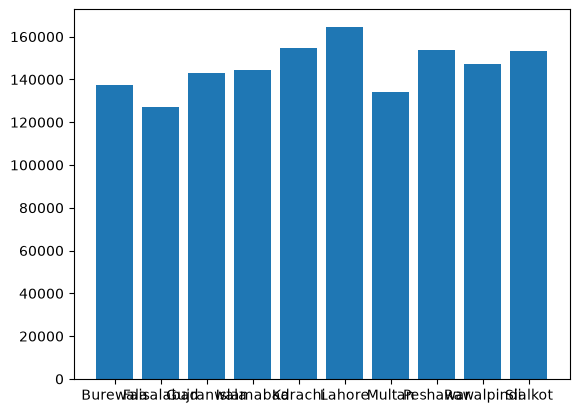

In [99]:
plt.bar(x=df['City'], height=df['sum'])

In [100]:
from matplotlib.image import imread

df1 = imread("lion.jpg")
df1

array([[[154, 167, 175],
        [154, 167, 175],
        [154, 167, 175],
        ...,
        [162, 173, 177],
        [161, 172, 176],
        [161, 172, 176]],

       [[154, 167, 175],
        [154, 167, 175],
        [154, 167, 175],
        ...,
        [162, 173, 177],
        [162, 173, 177],
        [161, 172, 176]],

       [[155, 168, 174],
        [155, 168, 174],
        [155, 168, 174],
        ...,
        [162, 173, 177],
        [162, 173, 177],
        [162, 173, 177]],

       ...,

       [[ 22,  14,  11],
        [ 29,  21,  18],
        [ 28,  20,  17],
        ...,
        [216, 162, 116],
        [217, 163, 117],
        [219, 165, 119]],

       [[ 25,  17,  14],
        [ 30,  22,  19],
        [ 29,  21,  18],
        ...,
        [207, 154, 110],
        [207, 154, 110],
        [209, 156, 112]],

       [[ 27,  19,  16],
        [ 32,  24,  21],
        [ 29,  21,  18],
        ...,
        [200, 147, 103],
        [199, 146, 102],
        [200, 147, 103]]

In [103]:
df1.size, df1.ndim, df1.shape

(479568, 3, (412, 388, 3))

In [106]:
df.isnull().sum()

Department    0
City          0
sum           0
mean          0
std           0
dtype: int64

In [109]:
x= df.drop("std", axis=1)
y = df['std']

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Categorical columns
categorical_columns = ["Department", "City"]
one_hot = OneHotEncoder()
# Create ColumnTransformer
ct = ColumnTransformer([
        ("one_hot",one_hot, categorical_columns)
    ],
    remainder='passthrough'
)

# Transform the data
X_encoded = ct.fit_transform(x)

print(X_encoded)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 240 stored elements and shape (60, 18)>
  Coords	Values
  (0, 0)	1.0
  (0, 6)	1.0
  (0, 16)	111080.0
  (0, 17)	111180.0
  (1, 0)	1.0
  (1, 7)	1.0
  (1, 16)	81294.0
  (1, 17)	81394.0
  (2, 0)	1.0
  (2, 8)	1.0
  (2, 16)	121801.0
  (2, 17)	121901.0
  (3, 0)	1.0
  (3, 9)	1.0
  (3, 16)	117973.0
  (3, 17)	118073.0
  (4, 0)	1.0
  (4, 10)	1.0
  (4, 16)	154648.0
  (4, 17)	154748.0
  (5, 0)	1.0
  (5, 11)	1.0
  (5, 16)	138157.0
  (5, 17)	138257.0
  (6, 0)	1.0
  :	:
  (53, 17)	126174.0
  (54, 5)	1.0
  (54, 10)	1.0
  (54, 16)	136106.0
  (54, 17)	136206.0
  (55, 5)	1.0
  (55, 11)	1.0
  (55, 16)	119786.0
  (55, 17)	119886.0
  (56, 5)	1.0
  (56, 12)	1.0
  (56, 16)	131134.0
  (56, 17)	131234.0
  (57, 5)	1.0
  (57, 13)	1.0
  (57, 16)	121030.0
  (57, 17)	121130.0
  (58, 5)	1.0
  (58, 14)	1.0
  (58, 16)	86500.0
  (58, 17)	86600.0
  (59, 5)	1.0
  (59, 15)	1.0
  (59, 16)	104879.0
  (59, 17)	104979.0


In [111]:
X_encoded

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 240 stored elements and shape (60, 18)>

In [112]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_encoded, y, test_size=0.2)

In [117]:
x_train.size,x_test.size

(192, 48)

In [118]:
y_train.size, y_test.size

(48, 12)

In [9]:
df= pd.read_csv("car-sales-extended-missing-data.csv")
df

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [10]:
df.isnull().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

In [16]:
# Handle missing values with pandas library

df['Make']=df['Make'].fillna("missing")
df['Colour']=df['Colour'].fillna("missing", inplace=True)
df['Doors']=df['Doors'].fillna(4,inplace=True)
df['Odometer (KM)']=df['Odometer (KM)'].fillna(df['Odometer (KM)'].mean(), inplace=True)


C:\Users\Admin\AppData\Local\Temp\ipykernel_25748\1311055707.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Colour']=df['Colour'].fillna("missing", inplace=True)
C:\Users\Admin\AppData\Local\Temp\ipykernel_25748\1311055707.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained a

In [17]:
df.isnull().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [18]:
df.dropna(inplace= True)

In [19]:
df.isnull().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [21]:
x = df.drop('Price', axis= 1)
y = df['Price']

In [22]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Categorical columns
categorical_columns = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
# Create ColumnTransformer
ct = ColumnTransformer([
        ("one_hot",one_hot, categorical_columns)
    ],
    remainder='passthrough'
)

# Transform the data
X_encoded = ct.fit_transform(x)

print(X_encoded)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>
  Coords	Values
  (0, 1)	1.0
  (0, 9)	1.0
  (0, 12)	1.0
  (0, 14)	35431.0
  (1, 0)	1.0
  (1, 6)	1.0
  (1, 13)	1.0
  (1, 14)	192714.0
  (2, 1)	1.0
  (2, 9)	1.0
  (2, 12)	1.0
  (2, 14)	84714.0
  (3, 3)	1.0
  (3, 9)	1.0
  (3, 12)	1.0
  (3, 14)	154365.0
  (4, 2)	1.0
  (4, 6)	1.0
  (4, 11)	1.0
  (4, 14)	181577.0
  (5, 1)	1.0
  (5, 8)	1.0
  (5, 12)	1.0
  (5, 14)	42652.0
  (6, 3)	1.0
  :	:
  (943, 14)	162523.0
  (944, 0)	1.0
  (944, 6)	1.0
  (944, 11)	1.0
  (944, 14)	163322.0
  (945, 3)	1.0
  (945, 5)	1.0
  (945, 12)	1.0
  (945, 14)	35820.0
  (946, 4)	1.0
  (946, 9)	1.0
  (946, 11)	1.0
  (946, 14)	155144.0
  (947, 2)	1.0
  (947, 6)	1.0
  (947, 12)	1.0
  (947, 14)	66604.0
  (948, 1)	1.0
  (948, 9)	1.0
  (948, 12)	1.0
  (948, 14)	215883.0
  (949, 3)	1.0
  (949, 6)	1.0
  (949, 12)	1.0
  (949, 14)	248360.0


In [25]:
X_encoded.shape, y.shape

((950, 15), (950,))

In [26]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X_encoded,y, test_size=0.2)


In [27]:
x_test

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 760 stored elements and shape (190, 15)>

In [28]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the numb

In [29]:
model.score(x_train,y_train)

0.8727475229822668

In [30]:
model.score(x_test,y_test)

0.331724540821003

In [32]:
df = pd.read_csv('car-sales-extended-missing-data.csv')
df

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0
...,...,...,...,...,...
995,Toyota,Black,35820.0,4.0,32042.0
996,NaN,White,155144.0,3.0,5716.0
997,Nissan,Blue,66604.0,4.0,31570.0
998,Honda,White,215883.0,4.0,4001.0


In [36]:
df.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

In [35]:
df.dropna(subset=['Price'], inplace= True)

In [37]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

car_imputor= SimpleImputer(strategy="constant", fill_value="missing")
door_imputor= SimpleImputer(strategy="constant", fill_value=4)
num_imputor= SimpleImputer(strategy="mean")

# create the columns 
car_features = ['Make','Colour']
door_features = ['Doors']
num_features = ['Odometer (KM)']

#create imputer

imputer = ColumnTransformer([("car_imputor",car_imputor,car_features),
                             ("door_imputor",door_imputor, door_features),
                             ("num_imputor", num_imputor,num_features)])

X = imputer.fit_transform(x)
X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [39]:
x = pd.DataFrame(X, columns= ["Make","Colour","Doors", "Odometer (KM)"])

In [41]:
x.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64